In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.feature_selection import r_regression
import math
import seaborn as sns
import icepython as icexl
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import datetime
from datetime import datetime, timedelta, date
import eventregistry
import re
from eventregistry import *
from zeep import Client, Settings
import io
from io import StringIO
from PIL import Image

In [16]:
current_date = datetime.date.today()
ed = current_date.strftime('%Y-%m-%d')
sd = (current_date - timedelta(days=365)).strftime('%Y-%m-%d')

symbols = ['GWMS 1!-ICE']
fields = ['volume', 'close',]

my_data = icexl.get_timeseries(symbols, fields, granularity='D', start_date=sd, end_date=ed)

symbols = ['GWMS 2!-ICE']
my_data2 = icexl.get_timeseries(symbols, fields, granularity='D', start_date=sd, end_date=ed)

dates, vols, values = zip(*my_data[1:])  
dates2, vols2, values2 = zip(*my_data2[1:])  

formatted_dates = [date for date in dates]

#sum_volumes = [v + v2 for v, v2 in zip(vols, vols2)]

num_points = len(formatted_dates)
indices = [0, num_points//3, 2*num_points//3, num_points-1]
selected_dates = [formatted_dates[i] for i in indices]

fig1 = make_subplots(
    rows=2, cols=1,
    shared_xaxes=False,  
    vertical_spacing=0.1,  
    row_heights=[0.99, 0.01] 
)


fig1.add_trace(go.Scatter(x=formatted_dates, y=values, mode='lines+markers',marker=dict(color='deepskyblue'), name='Winter 26'),row=1, col=1)

fig1.add_trace(go.Scatter(x=formatted_dates, y=values2, mode='lines+markers',marker=dict(color='darkviolet'), name='Summer 27'),row=1, col=1)


#fig.add_trace(go.Bar(x=formatted_dates, y=sum_volumes, name='Volumes'),row=2, col=1)

fig1.update_layout(title={
        'text': 'Summer 27 and Winter 26 Daily NBP Prices 12 Month Lag',
        'x': 0.5,  # Center the title
        'xanchor': 'center'
    },legend=dict(
        x=0.7,  # Position legend on the chart (left side)
        y=0.98,  # Near the top
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.8)', 
        bordercolor='lightgray',
        borderwidth=1
    ),
    title_x=0.5,
    yaxis_title='p/therm',
    showlegend=True,
    xaxis=dict(
        tickmode='array',
        tickvals=[formatted_dates[i] for i in indices],
        ticktext=selected_dates
    ),
       width=1600, 
    height=1600 ,font=dict(size=32)
)

fig1.show()

fig1.write_image(r"C:\Users\diarmuid.egan\OneDrive - Flogas Ireland\Microsoft Teams Chat Files\Pictures\Daily_tv\SandWNBP.png")

## Week on Week change

In [17]:
current_date = datetime.date.today()
ed = current_date.strftime('%Y-%m-%d')
sd = (current_date - timedelta(days=7)).strftime('%Y-%m-%d')

lom = ['GWM ' + str(i) + '!-ICE' for i in range(1,13)]

current_date = datetime.date.today()
ed = current_date.strftime('%Y-%m-%d')
sd = (current_date - timedelta(days=7)).strftime('%Y-%m-%d')

print(lom)
print(sd, ed)


['GWM 1!-ICE', 'GWM 2!-ICE', 'GWM 3!-ICE', 'GWM 4!-ICE', 'GWM 5!-ICE', 'GWM 6!-ICE', 'GWM 7!-ICE', 'GWM 8!-ICE', 'GWM 9!-ICE', 'GWM 10!-ICE', 'GWM 11!-ICE', 'GWM 12!-ICE']
2026-06-08 2026-06-15


In [18]:
## Last weeks data

current_date = datetime.date.today()
ed = current_date.strftime('%Y-%m-%d')
sd = (current_date - timedelta(days=7)).strftime('%Y-%m-%d')

lom = ['GWM ' + str(i) + '!-ICE' for i in range(1,13)]

my_data = icexl.get_timeseries(lom, ['Last'], granularity='D', start_date=sd, end_date=sd)
print(my_data)

#print(my_data)

last_week_p = my_data[1][1:]

## Current Data
wowf = ['ICE Theoretical Price']

wow_pull = icexl.get_quotes(lom, wowf)

current_theo_p = [i[1] for i in wow_pull[1:]]

def get_next_12_months():
    start_date = datetime.date.today() + datetime.timedelta(days=1)
    
    months_list = []
    current_date = start_date
    for _ in range(12):
        current_month = current_date.month
        current_year = current_date.year
        
        next_month = current_month + 1
        next_year = current_year
        if next_month > 12:
            next_month = 1
            next_year += 1
            
        current_date = datetime.date(next_year, next_month, 1)
        months_list.append(current_date.strftime('%b'))
    return months_list

labels = get_next_12_months()

fig2 = go.Figure()

# Add traces with marker/line colors INSIDE go.Scatter()
fig2.add_trace(go.Scatter(
    x=labels, 
    y=last_week_p, 
    mode='lines+markers', 
    name='Last Week',
    marker=dict(color='deepskyblue'),
    line=dict(color='deepskyblue')
))

fig2.add_trace(go.Scatter(
    x=labels, 
    y=current_theo_p, 
    mode='lines+markers', 
    name='Current Price',
    marker=dict(color='darkviolet'),
    line=dict(color='darkviolet')
))

fig2.update_layout(
    title={
        'text': 'Forward NBP Curve Change Week on Week',
        'x': 0.5,  # Center the title
        'xanchor': 'center'
    },
    xaxis_title='Month',
    yaxis_title='P/th',
    legend=dict(
        x=0.5,  # Position legend on the chart (left side)
        y=0.98,  # Near the top
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.8)', 
        bordercolor='lightgray',
        borderwidth=1
    ),
    hovermode='x unified',    width=1600, 
    height=800 ,font=dict(size=32)
)

fig2.write_image(r"C:\Users\diarmuid.egan\OneDrive - Flogas Ireland\Microsoft Teams Chat Files\Pictures\Daily_tv\forward_nbp.png")
fig2.show()

(('Time', 'GWM 1!-ICE.Last', 'GWM 2!-ICE.Last', 'GWM 3!-ICE.Last', 'GWM 4!-ICE.Last', 'GWM 5!-ICE.Last', 'GWM 6!-ICE.Last', 'GWM 7!-ICE.Last', 'GWM 8!-ICE.Last', 'GWM 9!-ICE.Last', 'GWM 10!-ICE.Last', 'GWM 11!-ICE.Last', 'GWM 12!-ICE.Last'), ('2026-06-08', 120.53, 120.88, 122.27, 122.76, 125.76, 127.26, 126.8, 124.03, 113.22, 96.9, 86.6, 83.11))


## Making the Gas and Baseload Prices

In [19]:
ss_months = {
    'apr': 20.51, 'may': 16.17, 'jun': 16.41, 'jul': 16.54, 
    'aug': 16.33, 'sep': 16.32, 'oct': 16.31, 'nov': 16.31, 
    'dec': 16.83, 'jan': 17.55, 'feb': 18.33, 'mar': 19.00 
}
Margin = 4.5
def get_next_24_months():
    start_date = datetime.date.today().replace(day=1)  
    months_list = []
    
    for i in range(1, 25):  
        year = start_date.year + (start_date.month + i - 1) // 12
        month = (start_date.month + i - 1) % 12 + 1
        date = datetime.date(year, month, 1)
        months_list.append(date.strftime('%b-%y'))
    
    return months_list
table_labels = get_next_24_months()
# DYNAMICALLY generate `ss` by extracting the month from your `table_labels`.
# `label[:3].lower()` takes 'Mar-26' and gets 'mar', looking it up in `ss_months`.
ss = [ss_months.get(label[:3].lower(), 16.0) for label in table_labels]
def Baseload_gen(gas, carbon, spark, fx):
    t1 = gas / (2.93071 * 0.4913 * fx)
    t2 = (0.18404 / 0.4913) * carbon
    ttl = float(t1) + float(t2) + float(Margin) + float(spark)
    return ttl
margin = np.linspace(2, 3.5, 24)
lom24 = ['GWM ' + str(i) + '!-ICE' for i in range(1, 25)]
fpf = ['ICE Theoretical Price']
f24_pull = icexl.get_quotes(lom24, fpf)
Gas_forward_theo_p = [i[1] for i in f24_pull[1:]]
CarbonM1_pull = icexl.get_quotes(['ECF 1!-ICN'], fpf)   # fixed variable overwriting
CarbonDec27_pull = icexl.get_quotes(['ECF 13!-ICN'], fpf) # fixed variable overwriting
Carbon = np.linspace(float(CarbonM1_pull[1][1]), float(CarbonDec27_pull[1][1]), 24)
GBPEUR = float(icexl.get_quotes(['EURGBP@FXP A0-FX'], ['Last'])[1][1])
Gas = [round(float(Gas_forward_theo_p[i] + margin[i]), 1) for i in range(24)]
Baseload = [round(float(Baseload_gen(Gas[i], Carbon[i], ss[i], GBPEUR)), 1) for i in range(24)]
row_labels = ['Period', 'NPB Gas p/th', 'Baseload €/MWh']
table_data = [table_labels, Gas, Baseload]
columns = [['<b>NPB Gas p/th</b>', '<b>Baseload €/MWh</b>']]
for i in range(len(table_labels)):
    columns.append([Gas[i], Baseload[i]])
fig4 = go.Figure(data=[go.Table(
    header=dict(
        values=['<b></b>'] + [f'<b>{label}</b>' for label in table_labels],
        fill_color='rgba(173, 216, 230, 0.5)',
        line_color='black',
        line_width=2,
        align='center',
        font=dict(size=32, color='black', family='Arial')
    ),
    cells=dict(
        values=columns,
        align=['center', 'center'], 
        fill_color='rgba(226, 233, 243, 0.3)',
        line_color='white',
        line_width=2,
        font=dict(size=32, color='black', family='Arial'),
        height=20)
)])
fig4.update_layout(
    width=3200,
    height=600,
    margin=dict(l=20, r=20, t=20, b=20)
)
fig4.show()
fig4.write_image(r"C:\Users\diarmuid.egan\OneDrive - Flogas Ireland\Microsoft Teams Chat Files\Pictures\Daily_tv\table.png")

In [20]:
urls = {'Temp':"https://app.enappsys.com/datadownload?code=isem/weather/tempair/national/history&currency=EUR&delimiter=comma&minavmax=false&pass=211225245243225231229237225238177178183161&res=hh&tag=csv&timezone=WET&user=diarmuid.egan@flogas.ie", 
        'Wind':'https://app.enappsys.com/datadownload?code=isem/elec/renewables/wind/onshore/forecast/history&currency=EUR&delimiter=comma&minavmax=false&pass=211225245243225231229237225238177178183161&res=hh&tag=csv&timezone=WET&user=diarmuid.egan@flogas.ie'}

def gen_url(base):
    current_date = datetime.date.today()
    current_date.strftime('%d/%m/%Y')
    #date_obj = datetime.strptime(input_date, '%d/%m/%Y')
    base = urls[base]
    start_date = (current_date ).strftime('%Y%m%d0000')
    end_date = (current_date + timedelta(days=6)).strftime('%Y%m%d2330')

    
    formatted_url = f"{base}&start={start_date}&end={end_date}"
    return formatted_url

def motel_data(base):
    response = requests.get(gen_url(base))
    if response.status_code != 200:
        raise Exception(f"Failed to fetch data: {response.status_code}")
    
    data = StringIO(response.text)
    df = pd.read_csv(data)

    df['Date (WET)'] = df['Date (WET)'].str.strip('[]')
    df['Date (WET)'] = pd.to_datetime(df['Date (WET)'], format='%d/%m/%Y %H:%M')
    df['Date (WET)'].astype('datetime64[ns]')
    df = df.drop(index=0).reset_index(drop=True)
    
    if base == 'Temp':
        df['LATEST_TEMP'] = df['LATEST'].astype(float)
        df['Date'] = df['Date (WET)']
        return df[['Date','LATEST_TEMP']]
        
    if base == 'Wind':
        df['LATEST_WIND'] = df['LATEST FORECAST (EnAppSys)'].astype(float)
        df['Date'] = df['Date (WET)']
        return df[['Date','LATEST_WIND']]

Wind = motel_data('Wind')
Temp = motel_data('Temp')

temp_summary = Temp.groupby(Temp['Date'].dt.date).agg(
    min_temp=('LATEST_TEMP', 'min'),
    max_temp=('LATEST_TEMP', 'max')
).reset_index()

# Create a timestamp at noon for each day to position the bars
temp_summary['Date'] = pd.to_datetime(temp_summary['Date']) + pd.Timedelta(hours=12)


# --- 3. Create the Plot ---
# Initialize figure with a secondary y-axis
fig3 = make_subplots(specs=[[{"secondary_y": True}]])

# Add Wind line trace to the primary y-axis
fig3.add_trace(
    go.Scatter(
        x=Wind['Date'],
        y=Wind['LATEST_WIND'],
        name='Wind',
        mode='lines',
        line=dict(color='darkviolet')
    ),
    secondary_y=False,
)

# Add Temperature range bars to the secondary y-axis
fig3.add_trace(
    go.Bar(
        x=temp_summary['Date'],
        y=temp_summary['max_temp'] - temp_summary['min_temp'], # Bar height is the range
        base=temp_summary['min_temp'], # Start the bar at the min temp
        name='Temp Range',
        marker=dict(color='deepskyblue', opacity=0.6), # Faint color with opacity
        width=1000 * 3600 * 4 # Bar width of 4 hours
    ),
    secondary_y=True,
)

# Add Min/Max labels for each temperature bar using annotations
for i, row in temp_summary.iterrows():
    # Max temp label (top of bar)
    fig3.add_annotation(x=row['Date'], y=row['max_temp'], yref="y2",
                       text=f"{row['max_temp']:.1f}", showarrow=False,
                       font=dict(color="black"), yshift=10)
    # Min temp label (bottom of bar)
    fig3.add_annotation(x=row['Date'], y=row['min_temp'], yref="y2",
                       text=f"{row['min_temp']:.1f}", showarrow=False,
                       font=dict(color="black"), yshift=-10)

fig3.update_layout(
    title={
        'text': 'Wind and Temperatrue Forecast',
        'x': 0.5,
        'xanchor': 'center'
    }, 
    legend_title="Series",
    showlegend=False,    width=1600, 
    height=800,    yaxis=dict(showgrid=False),  
    yaxis2=dict(showgrid=False),    font=dict(size=32))

fig3.update_yaxes(title_text="Wind (MW)", secondary_y=False, range=[0, 5000])
fig3.update_yaxes(title_text="Temperature (°C)", secondary_y=True)

fig3.data[1].showlegend = False

fig3.show()

fig3.write_image(r"C:\Users\diarmuid.egan\OneDrive - Flogas Ireland\Microsoft Teams Chat Files\Pictures\Daily_tv\wandt.png")

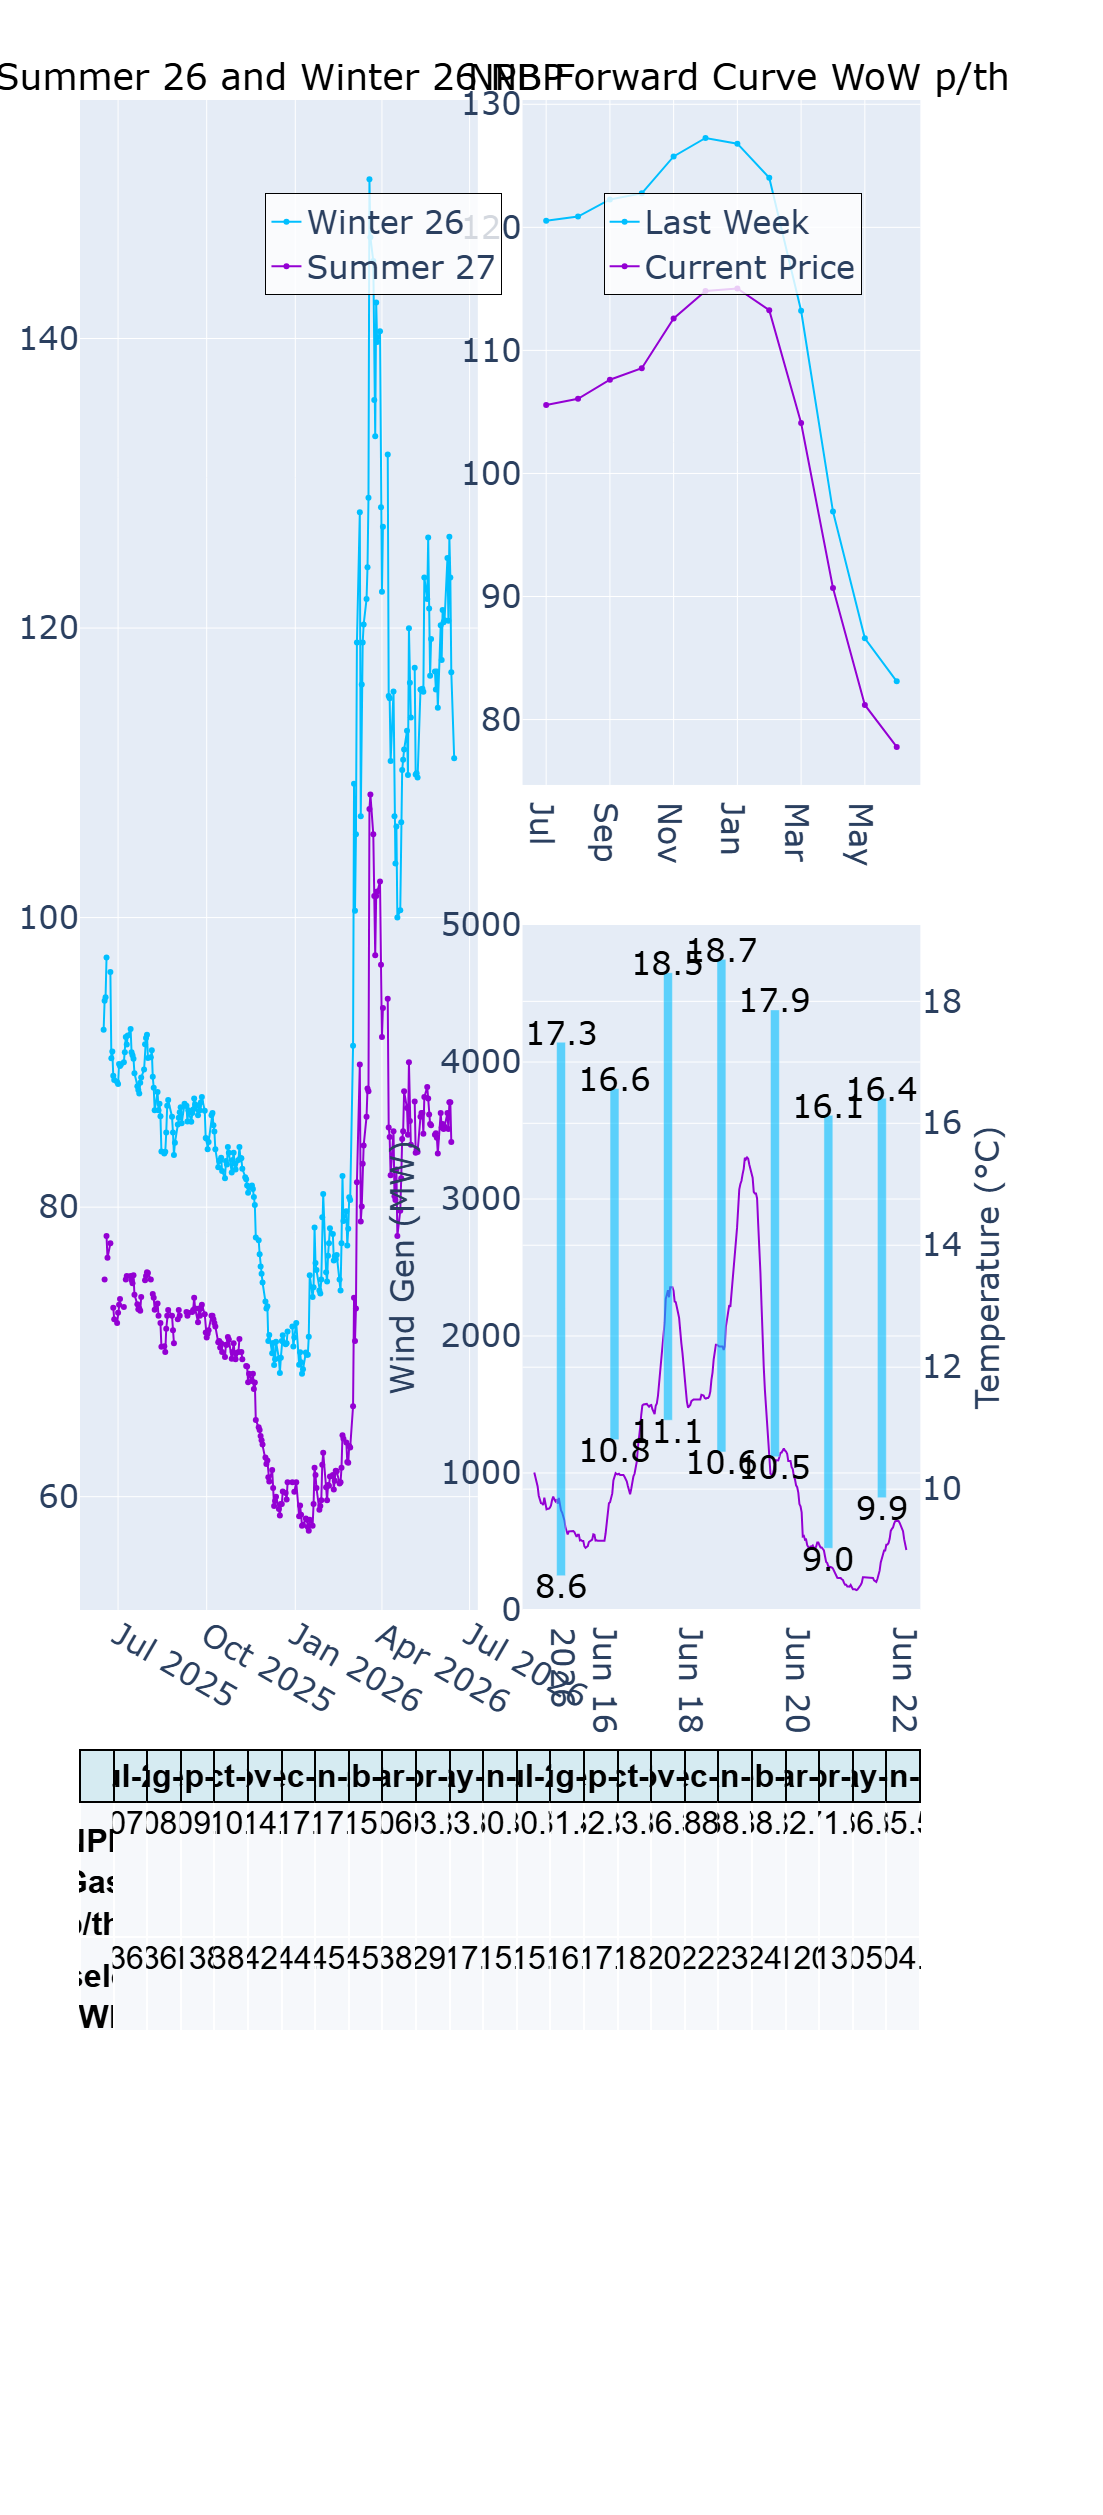

In [21]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create the subplot structure WITH subplot titles
specs = [
    [{"rowspan": 2, "type": "xy"}, {"type": "xy"}],
    [None, {"type": "xy", "secondary_y": True}],
    [{"colspan": 2, "type": "table"}, None]
]

fig = make_subplots(
    rows=3, cols=2,
    specs=specs,
    subplot_titles=("Summer 26 and Winter 26 NBP", " NPB Forward Curve WoW p/th", None, None),
    vertical_spacing=0.06,
    horizontal_spacing=0.05
)

# Add fig1 traces with legend assigned to first subplot
for trace in fig1.data:
    trace_copy = trace
    trace_copy.showlegend = True
    trace_copy.legend = "legend"  # Assign to first legend
    trace_copy.legendgroup = "group1"
    fig.add_trace(trace_copy, row=1, col=1)

# Add fig2 traces with legend assigned to second subplot
for trace in fig2.data:
    trace_copy = trace
    trace_copy.showlegend = True
    trace_copy.legend = "legend2"  # Assign to second legend
    trace_copy.legendgroup = "group2"
    fig.add_trace(trace_copy, row=1, col=2)

# Add fig3 traces
fig.add_trace(
    go.Scatter(
        x=Wind['Date'],
        y=Wind['LATEST_WIND'],
        name='Wind',
        mode='lines',
        line=dict(color='darkviolet'),
        showlegend=False
    ),
    row=2, col=2, secondary_y=False
)

fig.add_trace(
    go.Bar(
        x=temp_summary['Date'],
        y=(temp_summary['max_temp'] - temp_summary['min_temp']),
        base=temp_summary['min_temp'],
        name='Temp Range',
        marker=dict(color='deepskyblue', opacity=0.6),
        width=4 * 3600 * 1000,
        showlegend=False
    ),
    row=2, col=2, secondary_y=True
)

# Add annotations for temperature bars
for _, row_ in temp_summary.iterrows():
    fig.add_annotation(
        x=row_['Date'], 
        y=row_['max_temp'],
        xref='x3',
        yref='y4',
        text=f"{row_['max_temp']:.1f}",
        showarrow=False,
        font=dict(color="black", size=32),
        yshift=10
    )
    
    fig.add_annotation(
        x=row_['Date'],
        y=row_['min_temp'],
        xref='x3',
        yref='y4',
        text=f"{row_['min_temp']:.1f}",
        showarrow=False,
        font=dict(color="black", size=32),
        yshift=-10
    )

# Add fig4 (table)
for t in fig4.data:
    fig.add_trace(t, row=3, col=1)

# Update axis settings
fig.update_xaxes(title_text="", row=2, col=2)
fig.update_yaxes(title_text="Wind Gen (MW)", row=2, col=2, secondary_y=False, range=[0, 5000],title_font=dict(size=36),tickfont=dict(size=32))
fig.update_yaxes(title_text="Temperature (°C)", row=2, col=2, secondary_y=True,title_font=dict(size=36),tickfont=dict(size=32))

# CENTER the subplot titles
for i, annotation in enumerate(fig.layout.annotations):
    if i == 0:  # First subplot title (fig1)
        annotation.x = 0.223
        annotation.xanchor = 'center'
        annotation.font.size = 36
        annotation.font.color = 'black'
    elif i == 1:  # Second subplot title (fig2)
        annotation.x = 0.73
        annotation.xanchor = 'center'
        annotation.font.size = 36
        annotation.font.color = 'black'

# Final layout with INDIVIDUAL legends positioned on each subplot
fig.update_layout(
    height=2500,
    width=6400,
    
    # First legend (for fig1) - positioned in top-right of left subplot
    legend=dict(
        x=0.34,           # Centered horizontally over fig1
        y=0.96,           # Near the top
        xanchor='center',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.8)',  # Semi-transparent white background
        bordercolor='black',
        borderwidth=1,    font=dict(size=32)
    ),
    
    # Second legend (for fig2) - positioned in top-right of right subplot
    legend2=dict(
        x=0.73,           # Centered horizontally over fig2
        y=0.96,           # Near the top
        xanchor='center',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.8)',  # Semi-transparent white background
        bordercolor='black',
        borderwidth=1,    font=dict(size=32)
    )
)

fig.update_xaxes(
    title_font=dict(size=32),
    tickfont=dict(size=32)
)

fig.update_yaxes(
    title_font=dict(size=32),
    tickfont=dict(size=32)
)

fig.show()
fig.write_image(r"I:\Trading\FlogasNews\Daily_Image\Combined_IMG.png")

in_path  = r"I:\Trading\FlogasNews\Daily_Image\Combined_IMG.png"
out_path = os.path.splitext(in_path)[0] + "_cropped.png"

img = Image.open(in_path)

w, h = img.size 

box = (0, 0, max(0, w - 290), max(0, h - 450))


cropped = img.crop(box)
cropped.save(out_path)


## Monday Graph

## Monday Table